In [1]:
import pandas as pd
from joblib import load
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv(r'D:\Python\我的AI作品集\專案1_數學函數辨識\data\v1\function_dataset.csv')

In [3]:
X = df.drop(columns=['sample_id', 'label', 'noise_sigma'])
y = df['label']
sample_id = df['sample_id']     # sample_id 不拿去訓練模型

In [4]:
X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, sample_id, test_size=0.2, random_state=10, stratify=y)

In [5]:
# 載入最佳模型
best_model = load(r'D:\Python\我的AI作品集\專案1_數學函數辨識\models\v1\best_model.joblib')

In [6]:
y_pred = best_model.predict(X_test)

## 錯誤分析

In [7]:
# 建立測試資料表
test_all_df = pd.DataFrame({'sample_id': id_test.values,
                            'label': y_test.values,
                            'predicted_label': y_pred})

In [8]:
test_all_df['error'] = (test_all_df['label'] != test_all_df['predicted_label'])

In [9]:
print("----預測錯誤分析----")
print(f"測試樣本數: {len(test_all_df)}")
print(f"預測錯誤數量: {test_all_df['error'].sum()}")
print(f"整體錯誤率: {test_all_df['error'].mean():.2%}\n")

----預測錯誤分析----
測試樣本數: 800
預測錯誤數量: 143
整體錯誤率: 17.88%



In [10]:
metadata = pd.read_csv(r'D:\Python\我的AI作品集\專案1_數學函數辨識\data\v1\function_metadata.csv')

In [11]:
metadata = metadata[['sample_id', 'param_1', 'param_2', 'param_3', 'param_4', 'noise_sigma']]

In [12]:
# 加入 metadata
test_metadata = metadata.copy()

In [13]:
# 透過樣本編號對應到 metadata
error_metadata = test_all_df.merge(metadata, on='sample_id', how='left', validate='one_to_one')

In [14]:
# 找出 Sine/Cosine 之間的錯誤點
test_df = test_all_df[test_all_df['label'].isin(['sine', 'cosine'])].copy()
test_df = test_df.merge(test_metadata, on='sample_id', how='left', validate='one_to_one')

In [15]:
print(f"Sine被誤判成Cosine: {((test_df['label']=='sine') & (test_df['predicted_label']=='cosine')).sum()}")
sine_to_cosine = ((y_test == 'sine') & (y_pred == 'cosine'))
sine_cosine_metadata = error_metadata[(error_metadata['label']=='sine') &
                                      (error_metadata['predicted_label']=='cosine')]
print("錯誤樣本:")
print(sine_cosine_metadata[['sample_id', 'label', 'predicted_label', 'param_1',
                            'param_2', 'param_3', 'param_4', 'noise_sigma']].to_string(index=False))

Sine被誤判成Cosine: 4
錯誤樣本:
 sample_id label predicted_label  param_1  param_2  param_3  param_4  noise_sigma
      2727  sine          cosine 2.588530 2.392755 0.743937 0.883557     0.043728
      2719  sine          cosine 2.653467 3.370360 0.767241 0.713285     0.129856
      2866  sine          cosine 1.016743 2.730738 0.687624 0.052389     0.037746
      2531  sine          cosine 1.312797 3.375928 0.728364 0.895646     0.073758


In [16]:
print(f"\nCosine被誤判成Sine: {((test_df['label']=='cosine') & (test_df['predicted_label']=='sine')).sum()}")
cosine_to_sine = ((y_test == 'cosine') & (y_pred == 'sine'))
cosine_sine_metadata = error_metadata[(error_metadata['label']=='cosine') &
                                      (error_metadata['predicted_label']=='sine')]
print("錯誤樣本:")
print(cosine_sine_metadata[['sample_id', 'label', 'predicted_label', 'param_1',
                            'param_2', 'param_3', 'param_4', 'noise_sigma']].to_string(index=False))


Cosine被誤判成Sine: 1
錯誤樣本:
 sample_id  label predicted_label  param_1  param_2   param_3   param_4  noise_sigma
      3150 cosine            sine 1.538318 1.275734 -0.756376 -0.093071     0.025731


In [17]:
# 其他錯誤
others = test_all_df['error'].sum() - \
    ((test_df['label']=='sine') & (test_df['predicted_label']=='cosine')).sum() - \
    ((test_df['label']=='cosine') & (test_df['predicted_label']=='sine')).sum()
print(f"\n其他錯誤: {others}")
print("Sine / Cosine 的其他錯誤樣本:")
other_errors = test_df[(test_df['error']) &
    ~(((test_df['label'] == 'sine') & (test_df['predicted_label'] == 'cosine')) |
      ((test_df['label'] == 'cosine') & (test_df['predicted_label'] == 'sine')))]
print(other_errors[['sample_id', 'label', 'predicted_label',
                    'param_1', 'param_2', 'param_3', 'param_4', 'noise_sigma']].to_string(index=False))


其他錯誤: 138
Sine / Cosine 的其他錯誤樣本:
 sample_id  label predicted_label  param_1  param_2   param_3   param_4  noise_sigma
      2972   sine      reciprocal 0.586733 1.433519  0.584998  0.968800     0.017313
      2624   sine     exponential 0.512333 1.457153 -0.577926  0.451366     0.008916
      2963   sine       quadratic 2.788041 1.435764 -0.743275  0.854322     0.078646
      2604   sine      reciprocal 0.630057 1.043649  0.637004 -0.884349     0.015350
      3440 cosine       quadratic 0.700641 1.253436 -0.153228 -0.429745     0.010696
      3360 cosine     logarithmic 0.531047 1.715815  0.609564 -0.571901     0.015850
      3200 cosine       quadratic 0.682252 1.094040  0.058031 -0.477254     0.026332
      3123 cosine     logarithmic 1.257471 1.002833  0.691868 -0.867172     0.046208
      2561   sine     logarithmic 1.399558 1.080525 -0.585143 -0.179498     0.029459


## 以參數做錯誤分析

In [18]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["Microsoft JhengHei"]
plt.rcParams["axes.unicode_minus"] = False

In [19]:
test_para_df = test_all_df.merge(metadata, on='sample_id', how='left', validate='one_to_one')

In [20]:
parameters = ['param_1', 'param_2', 'param_3', 'param_4']
parameter_summary = []
for parameter in parameters:
    correct_data = test_para_df[test_all_df['error'] == False][parameter]
    error_data = test_para_df[test_all_df['error'] == True][parameter]
    parameter_summary.append({'Parameter': parameter,
                              'Correct Mean': correct_data.mean(),
                              'Correct Median': correct_data.median(),
                              'Error Mean': error_data.mean(),
                              'Error Median': error_data.median(),
                              'Mean Difference': (error_data.mean() - correct_data.mean())})
para_sum_df = pd.DataFrame(parameter_summary)

In [21]:
print("正確樣本 vs 錯誤樣本參數比較")
print(para_sum_df.to_string(index=False, formatters={'Correct Mean': '{:.3f}'.format,
                                                     'Correct Median': '{:.3f}'.format,
                                                     'Error Mean': '{:.3f}'.format,
                                                     'Error Median': '{:.3f}'.format,
                                                     'Mean Difference': '{:.3f}'.format}))

正確樣本 vs 錯誤樣本參數比較
Parameter Correct Mean Correct Median Error Mean Error Median Mean Difference
  param_1        0.705          1.101      0.183        0.300          -0.522
  param_2        1.069          0.790      0.601        0.440          -0.468
  param_3       -0.077          0.000      0.116        0.000           0.192
  param_4        0.034          0.000     -0.017        0.000          -0.051


### 分析每個參數的數值區間



In [22]:
print("各參數區間的錯誤率: ")
for parameter in parameters:
    # 使用四分位數分組, 每個區間大約包含相同數量的資料
    test_para_df[f'{parameter}_range'] = pd.qcut(test_para_df[parameter], q=4, duplicates='drop')
    analysis = test_para_df.groupby(f'{parameter}_range', observed=False).agg(
        total_samples=('error', 'count'),
        error_count=('error', 'sum'),
        error_rate=('error', 'mean')
    )
    print(analysis.to_string(formatters={'error_rate': '{:.2%}'.format}))
    print("\n")

各參數區間的錯誤率: 
                total_samples  error_count error_rate
param_1_range                                        
(-3.924, -0.5]            202           29     14.36%
(-0.5, 0.892]             198           88     44.44%
(0.892, 1.738]            200           17      8.50%
(1.738, 3.802]            200            9      4.50%


                 total_samples  error_count error_rate
param_2_range                                         
(-1.972, -0.25]            200           36     18.00%
(-0.25, 0.73]              200           45     22.50%
(0.73, 2.447]              200           42     21.00%
(2.447, 3.998]             200           20     10.00%


                  total_samples  error_count error_rate
param_3_range                                          
(-2.001, -0.551]            200           35     17.50%
(-0.551, 0.0]               258           42     16.28%
(0.0, 0.527]                142           12      8.45%
(0.527, 1.997]              200           54     2

In [23]:
# 儲存參數統計比較
para_sum_df.to_html(r'D:\Python\我的AI作品集\專案1_數學函數辨識\data\v1\parameter_analysis.html')

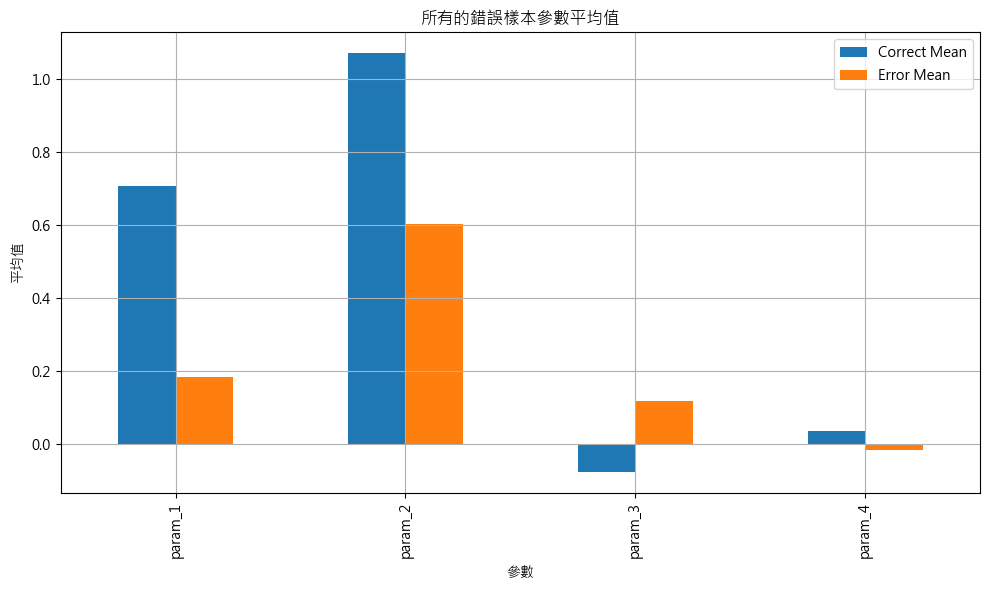

In [24]:
# 繪製圖表(正確/錯誤樣本的參數平均值)
plot_data = para_sum_df[['Parameter', 'Correct Mean', 'Error Mean']]
plot_data = plot_data.set_index('Parameter')
plot_data.plot(kind='bar', figsize=(10, 6))
plt.xlabel('參數')
plt.ylabel('平均值')
plt.title('所有的錯誤樣本參數平均值')
plt.xticks()
plt.grid()
plt.tight_layout()
plt.legend()
plt.savefig(r'D:\Python\我的AI作品集\專案1_數學函數辨識\data\v1\error_analysis.png')
plt.show()

## Sine / Cosine 錯誤分析

In [25]:
import numpy as np

In [26]:
cosine_to_sine_index = X_test.index[cosine_to_sine]
sine_to_cosine_index = X_test.index[sine_to_cosine]
cosine_sine_metadata = error_metadata[(error_metadata['label']=='cosine') &
                                      (error_metadata['predicted_label']=='sine')]
sine_cosine_metadata = error_metadata[(error_metadata['label']=='sine') &
                                      (error_metadata['predicted_label']=='cosine')]

In [27]:
print("----以下是 Sine / Cosine 錯誤分析的結果----")
print("Noise sigma:")
print(f"Sine被誤判成Cosine: {((test_df['label']=='sine') & (test_df['predicted_label']=='cosine')).sum()}")
print(f"Cosine被誤判成Sine: {((test_df['label']=='cosine') & (test_df['predicted_label']=='sine')).sum()}")

----以下是 Sine / Cosine 錯誤分析的結果----
Noise sigma:
Sine被誤判成Cosine: 4
Cosine被誤判成Sine: 1


In [28]:
# 顯示 Noise 統計
print(f"Sine → Cosine:\n{sine_cosine_metadata['noise_sigma'].describe()}\n")
print(f"Cosine → Sine:\n{cosine_sine_metadata['noise_sigma'].describe()}\n")

Sine → Cosine:
count    4.000000
mean     0.071272
std      0.042115
min      0.037746
25%      0.042233
50%      0.058743
75%      0.087783
max      0.129856
Name: noise_sigma, dtype: float64

Cosine → Sine:
count    1.000000
mean     0.025731
std           NaN
min      0.025731
25%      0.025731
50%      0.025731
75%      0.025731
max      0.025731
Name: noise_sigma, dtype: float64



In [29]:
bins = [0, 0.05, 0.10, 0.15, 0.20, np.inf]      # 將 noise_sigma 分成5個區間
labels = ['0.00 ~ 0.05',
          '0.05 ~ 0.10',
          '0.10 ~ 0.15',
          '0.15 ~ 0.20',
          '0.20+']
test_df['noise_range'] = pd.cut(test_df['noise_sigma'], bins=bins, labels=labels, include_lowest=True)
test_df['error'] = (test_df['label'] != test_df['predicted_label'])     # 判斷是否預測錯誤

In [30]:
# 計算每個 Noise 區間的錯誤率
noise_analysis = test_df.groupby('noise_range', observed=False).agg(total_samples=('error', 'count'),
                                                                    error_count=('error', 'sum'),
                                                                    error_rate=('error', 'mean'))

In [31]:
print(f"錯誤率分析:\n{noise_analysis.to_string(formatters={'error_rate': '{:.2%}'.format})}")

錯誤率分析:
             total_samples  error_count error_rate
noise_range                                       
0.00 ~ 0.05             99           11     11.11%
0.05 ~ 0.10             77            2      2.60%
0.10 ~ 0.15             22            1      4.55%
0.15 ~ 0.20              2            0      0.00%
0.20+                    0            0        NaN


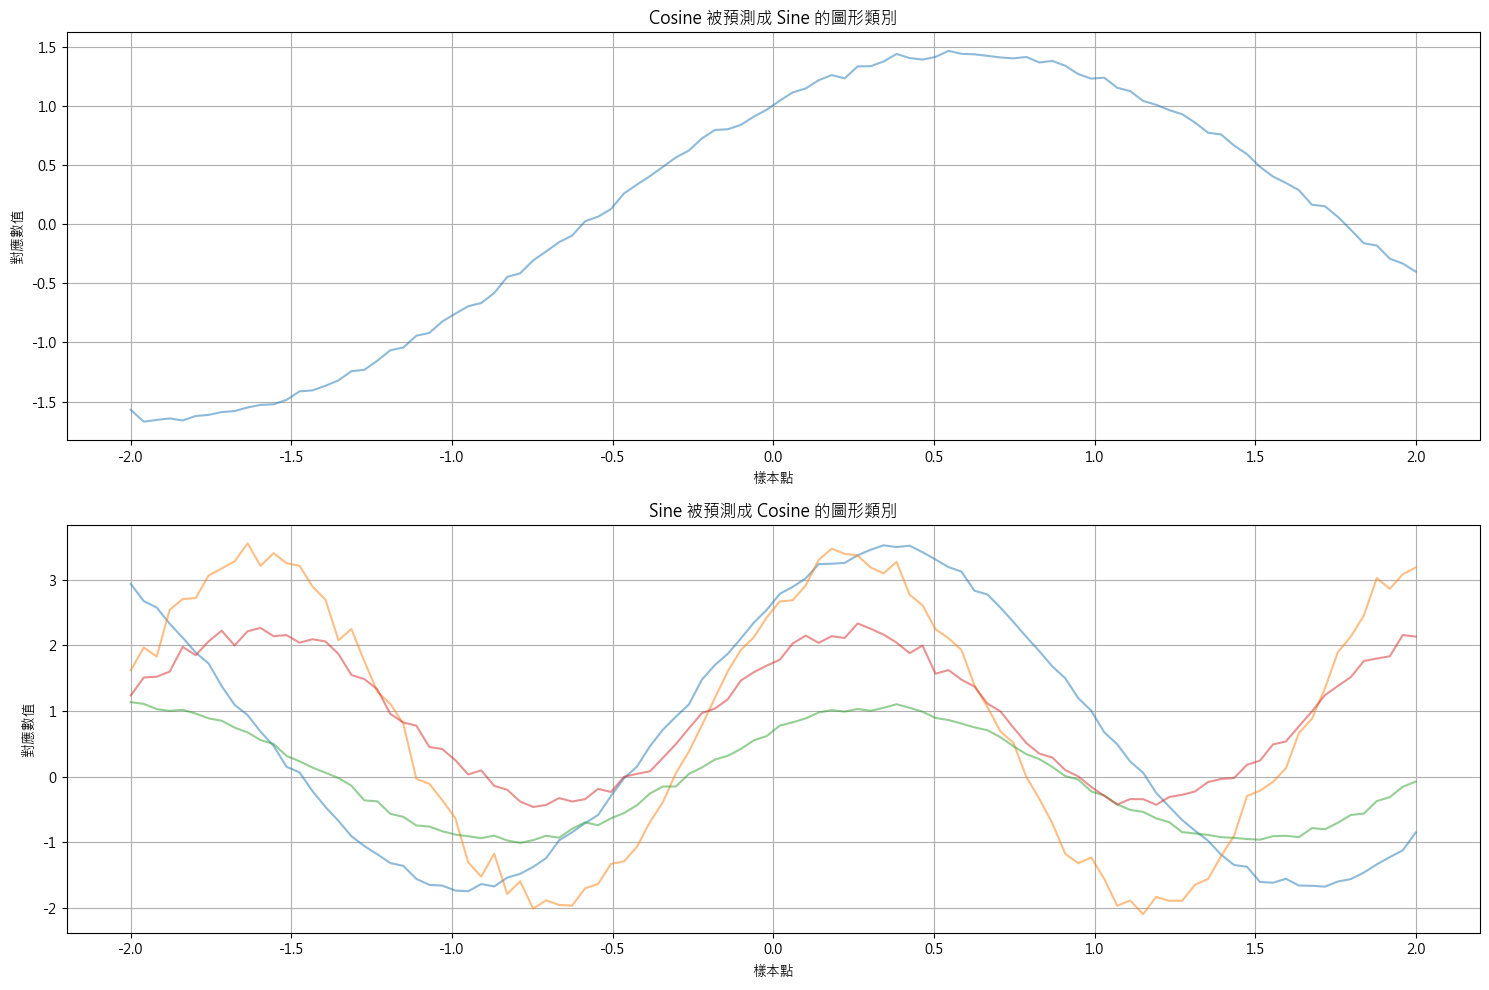

In [32]:
# 繪製圖表
xx = np.linspace(-2, 2, 100)            # Sample Points
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(2, 1, 1)
for index in cosine_to_sine_index:
    y_values = X_test.loc[index].values
    ax.plot(xx, y_values, alpha=0.5)
ax.set_xlabel("樣本點")
ax.set_ylabel("對應數值")
ax.set_title("Cosine 被預測成 Sine 的圖形類別")
ax.grid()

ax = fig.add_subplot(2, 1, 2)
for index in sine_to_cosine_index:
    y_values = X_test.loc[index].values
    ax.plot(xx, y_values, alpha=0.5)
ax.set_xlabel("樣本點")
ax.set_ylabel("對應數值")
ax.set_title("Sine 被預測成 Cosine 的圖形類別")
ax.grid()

plt.tight_layout()
plt.show()

### 參數分析

In [33]:
print("參數分析:")
print(f"樣本數: {len(test_df)}")
print(f"預測錯誤: {test_df['error'].sum()}")

參數分析:
樣本數: 200
預測錯誤: 14


In [34]:
sine_cosine_parameter_summary = []

In [35]:
for parameter in parameters:
    correct_data = test_df[test_df['error'] == False][parameter]
    error_data = test_df[test_df['error'] == True][parameter]
    sine_cosine_parameter_summary.append({'Parameter': parameter,
                                          'Correct Mean': correct_data.mean(),
                                          'Correct Median': correct_data.median(),
                                          'Error Mean': error_data.mean(),
                                          'Error Median': error_data.median(),
                                          'Mean Difference': (error_data.mean() - correct_data.mean())})
sine_cosine_para_sum_df = pd.DataFrame(sine_cosine_parameter_summary)

In [36]:
print("正確 vs 錯誤樣本參數比較:")
print(sine_cosine_para_sum_df.to_string(index=False, 
                                        formatters={'Correct Mean': '{:.3f}'.format,
                                                    'Correct Median': '{:.3f}'.format,
                                                    'Error Mean': '{:.3f}'.format,
                                                    'Error Median': '{:.3f}'.format,
                                                    'Mean Difference': '{:.3f}'.format}))

正確 vs 錯誤樣本參數比較:
Parameter Correct Mean Correct Median Error Mean Error Median Mean Difference
  param_1        1.761          1.791      1.300        1.137          -0.461
  param_2        2.480          2.559      1.762        1.435          -0.719
  param_3       -0.000         -0.071      0.192        0.597           0.193
  param_4        0.015          0.048      0.094       -0.020           0.079


In [37]:
# 分析每個參數的數值區間
print("各參數區間的錯誤率: ")
for parameter in parameters:
    # 使用四分位數分組, 每個區間大約包含相同數量的資料
    test_df[f'{parameter}_range'] = pd.qcut(test_df[parameter], q=4, duplicates='drop')
    analysis = test_df.groupby(f'{parameter}_range', observed=False).agg(
        total_samples=('error', 'count'),
        error_count=('error', 'sum'),
        error_rate=('error', 'mean')
    )
    print(analysis.to_string(formatters={'error_rate': '{:.2%}'.format}))
    print("\n")

各參數區間的錯誤率: 
                total_samples  error_count error_rate
param_1_range                                        
(0.511, 1.208]             50            7     14.00%
(1.208, 1.756]             50            4      8.00%
(1.756, 2.27]              50            0      0.00%
(2.27, 3.0]                50            3      6.00%


                             total_samples  error_count error_rate
param_2_range                                                     
(0.9999999999999999, 1.685]             50            9     18.00%
(1.685, 2.454]                          50            2      4.00%
(2.454, 3.139]                          50            1      2.00%
(3.139, 3.986]                          50            2      4.00%


                   total_samples  error_count error_rate
param_3_range                                           
(-0.781, -0.374]              50            4      8.00%
(-0.374, -0.0545]             50            1      2.00%
(-0.0545, 0.437]              

In [38]:
# 儲存參數統計比較
sine_cosine_para_sum_df.to_html(r'D:\Python\我的AI作品集\專案1_數學函數辨識\data\v1\sine_cosine_parameter_analysis.html')

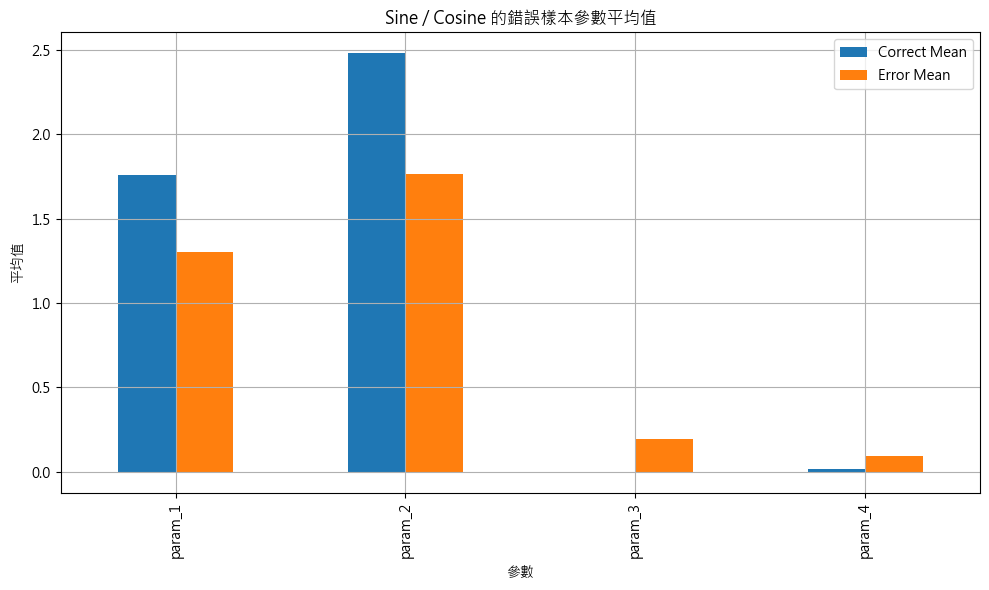

In [39]:
# 繪製圖表(正確/錯誤樣本的參數平均值)
plot_data = sine_cosine_para_sum_df[['Parameter', 'Correct Mean', 'Error Mean']]
plot_data = plot_data.set_index('Parameter')
plot_data.plot(kind='bar', figsize=(10, 6))
plt.xlabel('參數')
plt.ylabel('平均值')
plt.title('Sine / Cosine 的錯誤樣本參數平均值')
plt.xticks()
plt.grid()
plt.tight_layout()
plt.legend()
plt.savefig(r'D:\Python\我的AI作品集\專案1_數學函數辨識\data\v1\sine_cosine_error_analysis.png')
plt.show()